# Clasificación de Riesgo Crediticio con Regresión Logística Multiclase
## Dataset: Credit Score Classification — Kaggle

> 🔗 **Fuente:** [Kaggle – Credit Score Classification](https://www.kaggle.com/datasets/parisrohan/credit-score-classification?select=train.csv)

---

## ¿Qué es el Credit Score y por qué clasificarlo?

El **score crediticio** es una puntuación numérica que resume el historial financiero de una persona  
y permite a bancos e instituciones estimar la probabilidad de que un cliente **incumpla sus obligaciones**.  
Automatizar esta clasificación con Machine Learning reduce la subjetividad, acelera decisiones y escala a millones de clientes.

En este proyecto se implementa un clasificador **multiclase hecho a mano** — sin usar `sklearn.linear_model` —  
basado en **Regresión Logística** con el esquema **One-vs-All (OvA)**, optimizado mediante  
el algoritmo cuasi-Newton **L-BFGS-B** de `scipy`.

### Clases del problema

| `classID` | Etiqueta   | Descripción                                              |
|:---------:|:-----------|:---------------------------------------------------------|
| 0         | `Poor`     | Alto riesgo de impago; acceso crediticio muy limitado    |
| 1         | `Standard` | Riesgo moderado; cliente con historial regular           |
| 2         | `Good`     | Bajo riesgo; cliente confiable con buen historial        |

---

### Columnas principales del dataset

| Columna                    | Tipo      | Descripción                                               |
|:---------------------------|:----------|:----------------------------------------------------------|
| `Age`                      | Numérica  | Edad del cliente                                          |
| `Annual_Income`            | Numérica  | Ingreso anual (USD)                                       |
| `Num_Bank_Accounts`        | Numérica  | Número de cuentas bancarias activas                       |
| `Num_Credit_Card`          | Numérica  | Cantidad de tarjetas de crédito                           |
| `Interest_Rate`            | Numérica  | Tasa de interés promedio (%)                              |
| `Num_of_Loan`              | Numérica  | Número de préstamos activos                               |
| `Delay_from_due_date`      | Numérica  | Días promedio de retraso en pagos                         |
| `Num_of_Delayed_Payment`   | Numérica  | Total de pagos retrasados                                 |
| `Outstanding_Debt`         | Numérica  | Deuda pendiente total (USD)                               |
| `Credit_History_Age`       | Numérica  | Antigüedad del historial crediticio (meses)               |
| `Monthly_Balance`          | Numérica  | Balance mensual promedio (USD)                            |
| `Credit_Score`             | Categórica| **Variable objetivo** codificada como 0 / 1 / 2           |




---

## 1. Importación de Librerías


In [1]:
import numpy as np                        # Álgebra lineal y operaciones vectorizadas
import pandas as pd                       # Carga y manipulación del dataset
from matplotlib import pyplot             # Visualización de curvas de convergencia
import matplotlib.pyplot as plt           # Gráficas profesionales
from scipy import optimize                # Optimizador L-BFGS-B
from sklearn.model_selection import train_test_split  # División train/test


---

## 2. Carga y Balanceo del Dataset

### ¿Por qué balancear las clases?

Los datasets de crédito son típicamente **desbalanceados**: la clase `Standard` suele dominar  
mientras que `Poor` y `Good` son minoritarias. Entrenar sobre datos desbalanceados sesga al modelo  
hacia la clase mayoritaria, ignorando las minorías que suelen ser las más importantes para el negocio.

**Solución: Submuestreo (Undersampling)** de las clases mayoritarias hasta igualar la clase con  
menor cantidad de ejemplos. Se identifica el tamaño mínimo entre todas las clases y se recortan  
las demás usando `pandas.DataFrame.sample` con `replace=False` (muestreo sin reemplazo).

In [2]:
# ── Carga del dataset pre-procesado ──────────────────────────────────────────
df = pd.read_csv('D:/Universidad/5to Semestre/Inteligencia Artificial/Laboratorio 04/Clasificacion Multiclase Tabular/dataset_sanado.csv')

print("Distribución original de clases:")
print(df['Credit_Score'].value_counts().sort_index())
print()

# ── Separar clases para el balanceo ──────────────────────────────────────────
df_0 = df[df['Credit_Score'] == 0]   # Poor     (clase minoritaria)
df_1 = df[df['Credit_Score'] == 1]   # Standard (clase mayoritaria)
df_2 = df[df['Credit_Score'] == 2]   # Good

# Tamaño de la clase con MENOR cantidad de ejemplos
n_minimo = min(len(df_0), len(df_1), len(df_2))
print(f"Clase con menor cantidad de ejemplos: {n_minimo} muestras")

# Submuestreo sin reemplazo: cada clase se recorta a n_minimo filas
df_0_under = df_0.sample(n=n_minimo, random_state=42)
df_1_under = df_1.sample(n=n_minimo, random_state=42)
df_2_under = df_2.sample(n=n_minimo, random_state=42)

# Combina las tres clases balanceadas y baraja las filas
df_balanceado = pd.concat([df_0_under, df_1_under, df_2_under]).sample(frac=1, random_state=42).reset_index(drop=True)

print("Distribución tras balanceo (undersampling):")
print(df_balanceado['Credit_Score'].value_counts().sort_index())


Distribución original de clases:
Credit_Score
0    28998
1    53174
2    17828
Name: count, dtype: int64

Clase con menor cantidad de ejemplos: 17828 muestras
Distribución tras balanceo (undersampling):
Credit_Score
0    17828
1    17828
2    17828
Name: count, dtype: int64


### Extracción de Matrices X e y

Se separan las características ($X$) de la variable objetivo ($y$) y se fuerzan los tipos numéricos.


In [3]:
# Separa características (X) y etiquetas (y)
X = df_balanceado.drop(columns=['Credit_Score']).values   # (m, n)  → matriz de características
y = df_balanceado['Credit_Score'].values                  # (m,)    → vector de etiquetas 0/1/2

# Fuerza tipo float para garantizar compatibilidad con NumPy y evitar errores de tipo
X = np.array(X, dtype=float)
y = np.array(y, dtype=int)

# Dimensiones globales del problema
m          = y.size              # Número total de ejemplos
n          = X.shape[1]          # Número de características por ejemplo
num_labels = 3                   # Clases: 0=Poor, 1=Standard, 2=Good

print(f"Ejemplos totales (m):      {m:,}")
print(f"Características (n):       {n}")
print(f"Número de clases:          {num_labels}")
print(f"Tipo de X:                 {X.dtype}")


Ejemplos totales (m):      53,484
Características (n):       44
Número de clases:          3
Tipo de X:                 float64


---

## 3. Normalización de Características

### ¿Por qué normalizar?

Las características del dataset tienen **escalas muy distintas**:  
`Annual_Income` puede estar en miles de dólares mientras que `Num_Bank_Accounts` va de 0 a 10.  
Sin normalizar, el optimizador converge lentamente o se queda atrapado en mínimos locales,  
ya que los gradientes de características con mayor escala dominan la actualización de $\theta$.

La **estandarización Z-score** transforma cada característica $j$ así:

$$x_j^{\text{norm}} = \frac{x_j - \mu_j}{\sigma_j}$$

donde $\mu_j$ es la media y $\sigma_j$ la desviación estándar de la columna $j$.  
El resultado es que cada columna queda con **media $\approx 0$** y **desviación estándar $\approx 1$**.

> Los parámetros $\mu$ y $\sigma$ se calculan sobre el conjunto completo y deben guardarse  
> para aplicar la misma transformación sobre datos nuevos en producción.


In [4]:
def featureNormalize(X):
    mu    = np.mean(X, axis=0)   # Media por columna  → (n,)
    sigma = np.std(X,  axis=0)   # Std  por columna   → (n,)

    # Previene división por cero en columnas constantes (std == 0)
    sigma[sigma == 0] = 1

    X_norm = (X - mu) / sigma    # Estandarización vectorizada
    return X_norm, mu, sigma

# Aplica la normalización al dataset completo
X, mu, sigma = featureNormalize(X)

print("Verificación post-normalización:")
print(f"  Media global de X:  {X.mean():.6f}  (esperado ≈ 0)")
print(f"  Std  global de X:   {X.std():.6f}  (esperado ≈ 1)")


Verificación post-normalización:
  Media global de X:  0.000000  (esperado ≈ 0)
  Std  global de X:   1.000000  (esperado ≈ 1)


---

## 4. División Train / Test

Se reserva el **20%** de los datos para evaluar el modelo en datos que nunca vio durante el entrenamiento.


In [5]:
# Divide en conjuntos de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y  # stratify conserva proporción de clases
)

print(f"Ejemplos de entrenamiento: {X_train.shape[0]:,}")
print(f"Ejemplos de prueba:        {X_test.shape[0]:,}")
print(f"Características:           {X_train.shape[1]}")


Ejemplos de entrenamiento: 42,787
Ejemplos de prueba:        10,697
Características:           44


---

## 5. Funciones Matemáticas del Modelo

### 5.1 Función Sigmoide

La **sigmoide** mapea cualquier número real al intervalo $(0, 1)$, interpretable como probabilidad:

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

En clasificación logística, la hipótesis es $h_\theta(x) = \sigma(\theta^T x)$,  
que representa la probabilidad estimada de que $x$ pertenezca a la clase positiva.


In [6]:
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))


### 5.2 Función de Costo (Log-Loss sin regularización)

La **entropía cruzada binaria** mide qué tan lejos están las predicciones de las etiquetas reales:

$$J(\theta) = -\frac{1}{m} \left[ \sum_{i=1}^{m} y^{(i)} \log\bigl(h_\theta(x^{(i)})\bigr) + \left(1 - y^{(i)}\right) \log\bigl(1 - h_\theta(x^{(i)})\bigr) \right]$$

> **Nota:** esta función se usa internamente como auxiliar de verificación.  
> El entrenamiento real usa `lrCostFunction` con regularización.


In [7]:
def calcularCosto(theta, X, y):
    m = y.size
    h = sigmoid(X.dot(theta.T))  # Hipótesis: h = σ(X·θᵀ) → (m,)
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))
    return J


### 5.3 Función de Costo Regularizada + Gradiente

Esta es la función **central del modelo**. Extiende `calcularCosto` con dos elementos clave:

**a) Regularización L2 (Ridge):** penaliza parámetros grandes para evitar sobreajuste:

$$J_{\text{reg}}(\theta) = -\frac{1}{m}\left[\sum_{i=1}^{m} y^{(i)}\log h + (1-y^{(i)})\log(1-h)\right] + \frac{\lambda}{2m}\sum_{j=1}^{n}\theta_j^2$$

> ⚠️ El término de bias $\theta_0$ **nunca se regulariza** (convención estándar).

**b) Gradiente:** necesario para que `scipy.optimize` actualice $\theta$ eficientemente:

$$\frac{\partial J}{\partial \theta_0} = \frac{1}{m}(h - y)^T x_0$$

$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m}(h - y)^T x_j + \frac{\lambda}{m}\theta_j \quad (j \geq 1)$$

La función devuelve la tupla `(J, grad)` porque `scipy.optimize.minimize` con `jac=True`  
espera que la función objetivo retorne costo y gradiente en una sola llamada.


In [8]:
def lrCostFunction(theta, X, y, lambda_):
    m = y.size

    # Convierte etiquetas booleanas (resultado de y == c) a enteros 0/1
    if y.dtype == bool:
        y = y.astype(int)

    # ── Hipótesis ─────────────────────────────────────────────────────────────
    # h = σ(X·θᵀ): probabilidad estimada de clase positiva para cada ejemplo
    # Forma: (m,)
    h = sigmoid(X.dot(theta.T))

    # ── Preparar theta para regularización ───────────────────────────────────
    # Copia de theta donde se anula θ₀ (bias) para no regularizarlo
    temp    = theta.copy()
    temp[0] = 0               # θ₀ no entra en la penalización L2

    # ── Costo con regularización L2 ───────────────────────────────────────────
    # Primer término: log-loss (entropía cruzada binaria)
    # Segundo término: penalización Ridge sobre los pesos (excluye bias)
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))         + (lambda_ / (2 * m)) * np.sum(np.square(temp))

    # ── Gradiente ─────────────────────────────────────────────────────────────
    # Primera parte: gradiente del error de predicción → (n+1,)
    grad = (1 / m) * (h - y).dot(X)
    # Segunda parte: gradiente de la regularización (0 para θ₀ por temp[0]=0)
    grad = grad + (lambda_ / m) * temp

    # scipy.optimize requiere (J, grad) cuando jac=True
    return J, grad


---

## 6. Entrenamiento: One-vs-All con Optimización L-BFGS-B

### ¿Qué es el enfoque One-vs-All?

Para clasificar entre $K = 3$ clases con un modelo binario, se entrena **un clasificador por clase**:

| Clasificador | Clase positiva | Clase negativa        |
|:------------:|:---------------|:----------------------|
| $c = 0$      | `Poor`         | `Standard` + `Good`  |
| $c = 1$      | `Standard`     | `Poor` + `Good`      |
| $c = 2$      | `Good`         | `Poor` + `Standard`  |

Al predecir, se evalúan los 3 clasificadores y se elige la clase con mayor probabilidad:

$$\hat{y} = \arg\max_{c \in \{0,1,2\}} \; \sigma\!\left(\theta^{(c)T} x\right)$$

### ¿Por qué L-BFGS-B en lugar de descenso de gradiente manual?

El descenso de gradiente estándar requiere ajustar manualmente la tasa de aprendizaje $\alpha$  
y puede converger muy lentamente. **L-BFGS-B** (*Limited-memory Broyden–Fletcher–Goldfarb–Shanno with Bounds*) es un método cuasi-Newton que:

- Aproxima la **curvatura** (Hessiano) para dar pasos de actualización adaptativos.
- Converge en **órdenes de magnitud menos iteraciones** que el gradiente estándar.
- Solo requiere $J$ y $\nabla J$ — no necesita el Hessiano explícito.


In [9]:
def OneVsAllOM(X, y, num_labels, lambda_):
    m, n = X.shape   # m = ejemplos, n = características (sin bias)

    # Matriz de resultados: cada fila c almacena θ⁽ᶜ⁾
    # Dimensión: (num_labels, n+1)  → +1 por el término de bias θ₀
    all_theta = np.zeros((num_labels, n + 1))

    # Agrega columna de unos al inicio: X pasa de (m, n) a (m, n+1)
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    # ── Bucle OvA: un clasificador por clase ──────────────────────────────────
    for c in np.arange(num_labels):

        # Inicializa θ en cero para evitar simetrías en el arranque
        initial_theta = np.zeros(n + 1)

        # Límite de iteraciones del optimizador (400 es suficiente con L-BFGS-B)
        options = {'maxiter': 400}

        # scipy.optimize.minimize con L-BFGS-B:
        # · fun    = lrCostFunction    — función objetivo
        # · x0     = initial_theta     — punto de inicio
        # · args   = (X, y==c, λ)      — (y == c) convierte etiquetas a binario {False/True}
        # · jac    = True              — fun devuelve (J, grad) simultáneamente
        # · method = 'L-BFGS-B'       — optimizador cuasi-Newton eficiente
        res = optimize.minimize(
            lrCostFunction,
            initial_theta,
            (X, (y == c), lambda_),
            jac=True,
            method='L-BFGS-B',
            options=options
        )

        # Guarda los parámetros óptimos del clasificador c
        all_theta[c] = res.x   # res.x: vector θ que minimizó el costo

    return all_theta


### Ejecución del Entrenamiento

Se entrena el modelo OvA sobre `X_train` con $\lambda = 0.01$.


In [10]:
lambda_   = 0.01
all_theta = OneVsAllOM(X_train, y_train, num_labels, lambda_)

print(f"Shape de all_theta: {all_theta.shape}")
print("  → Filas: un θ por clase (3)")
print(f"  → Columnas: {all_theta.shape[1]} parámetros (1 bias + {n} características)")


Shape de all_theta: (3, 45)
  → Filas: un θ por clase (3)
  → Columnas: 45 parámetros (1 bias + 44 características)


---

## 7. Predicción

La función de predicción evalúa los 3 clasificadores para cada ejemplo y asigna la clase  
con la mayor probabilidad estimada por la sigmoide.


### Gráficas de Costo por Clasificador (One-vs-All)

Para cada uno de los **3 clasificadores binarios** del esquema OvA, se grafica la evolución del costo  
a lo largo de iteraciones de submuestreo del optimizador. Esto permite verificar la convergencia  
de cada clasificador de forma independiente.

Se re-ejecuta el entrenamiento registrando el costo en cada iteración mediante un *callback*  
interno de `scipy.optimize.minimize`, lo que no altera la lógica de entrenamiento original.


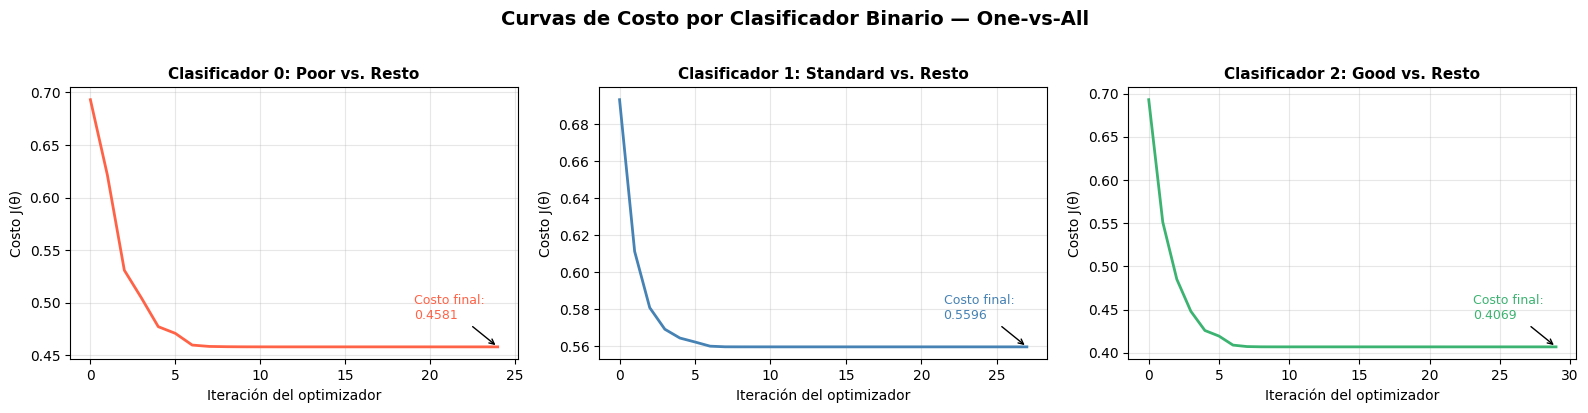

In [11]:
# ── Re-entrenamiento con registro de costo para visualización ─────────────────
# Se usa un callback de scipy para capturar el costo en cada iteración
# sin modificar la lógica del modelo ni las funciones matemáticas base.

nombres_clases = {0: 'Poor', 1: 'Standard', 2: 'Good'}
colores_clases = {0: 'tomato', 1: 'steelblue', 2: 'mediumseagreen'}

# Prepara X_train con columna de bias para el registro de costo
m_tr, n_tr = X_train.shape
X_train_bias = np.concatenate([np.ones((m_tr, 1)), X_train], axis=1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Curvas de Costo por Clasificador Binario — One-vs-All', fontsize=14, fontweight='bold', y=1.02)

for c in range(num_labels):
    historial_costo = []   # Registra el costo en cada llamada a lrCostFunction

    # Wrapper que captura el costo sin alterar lrCostFunction original
    def objetivo_con_registro(theta, X, y_bin, lambda_, historial=historial_costo):
        J, grad = lrCostFunction(theta, X, y_bin, lambda_)
        historial.append(J)
        return J, grad

    initial_theta = np.zeros(n_tr + 1)
    optimize.minimize(
        objetivo_con_registro,
        initial_theta,
        (X_train_bias, (y_train == c), lambda_),
        jac=True,
        method='L-BFGS-B',
        options={'maxiter': 400}
    )

    ax = axes[c]
    ax.plot(historial_costo, color=colores_clases[c], linewidth=2)
    ax.set_title(f'Clasificador {c}: {nombres_clases[c]} vs. Resto', fontsize=11, fontweight='bold')
    ax.set_xlabel('Iteración del optimizador', fontsize=10)
    ax.set_ylabel('Costo J(θ)', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.annotate(f'Costo final:\n{historial_costo[-1]:.4f}',
                xy=(len(historial_costo)-1, historial_costo[-1]),
                xytext=(-60, 20), textcoords='offset points',
                arrowprops=dict(arrowstyle='->', color='black'),
                fontsize=9, color=colores_clases[c])

plt.tight_layout()
plt.show()


### Gráfica de Precisión por Clasificador Binario

Se visualiza la **precisión (accuracy)** de cada clasificador binario en los conjuntos de  
entrenamiento y prueba. Esto complementa las curvas de costo y permite detectar sobreajuste  
por clasificador: si la accuracy de entrenamiento es muy alta pero la de prueba es baja, el  
clasificador sobreajustó para esa clase específica.


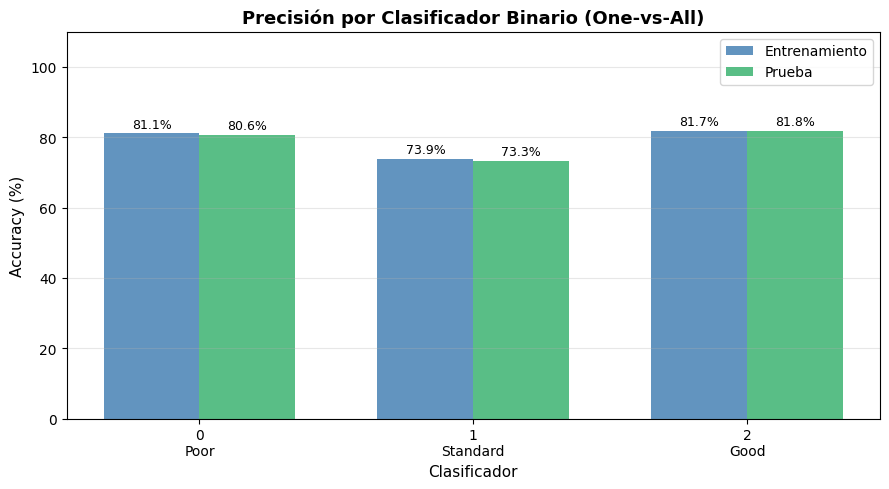

In [12]:
# ── Precisión por clasificador binario ────────────────────────────────────────
# Para cada clase c se evalúa la accuracy del clasificador binario c sobre train y test.

m_te = X_test.shape[0]
X_test_bias  = np.concatenate([np.ones((m_te, 1)),  X_test],  axis=1)
# X_train_bias ya fue definida en la celda anterior

acc_train_por_clase = []
acc_test_por_clase  = []

for c in range(num_labels):
    theta_c = all_theta[c]   # Parámetros del clasificador c (ya entrenado)

    # Predicción binaria: 1 si prob > 0.5, 0 si no
    pred_tr = (sigmoid(X_train_bias.dot(theta_c)) >= 0.5).astype(int)
    pred_te = (sigmoid(X_test_bias.dot(theta_c))  >= 0.5).astype(int)

    y_bin_tr = (y_train == c).astype(int)
    y_bin_te = (y_test  == c).astype(int)

    acc_train_por_clase.append(np.mean(pred_tr == y_bin_tr) * 100)
    acc_test_por_clase.append(np.mean(pred_te == y_bin_te)  * 100)

# ── Gráfica de barras agrupadas ───────────────────────────────────────────────
clases_labels = [f'{c}\n{nombres_clases[c]}' for c in range(num_labels)]
x = np.arange(num_labels)
ancho = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
barras_tr = ax.bar(x - ancho/2, acc_train_por_clase, ancho, label='Entrenamiento', color='steelblue',    alpha=0.85)
barras_te = ax.bar(x + ancho/2, acc_test_por_clase,  ancho, label='Prueba',        color='mediumseagreen', alpha=0.85)

ax.set_title('Precisión por Clasificador Binario (One-vs-All)', fontsize=13, fontweight='bold')
ax.set_xlabel('Clasificador', fontsize=11)
ax.set_ylabel('Accuracy (%)', fontsize=11)
ax.set_xticks(x)
ax.set_xticklabels(clases_labels, fontsize=10)
ax.set_ylim(0, 110)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Anotar valores sobre las barras
for bar in barras_tr:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in barras_te:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [13]:
def predictOneVsAll(all_theta, X):

    m          = X.shape[0]          # Número de ejemplos
    num_labels = all_theta.shape[0]  # Número de clasificadores (3)

    # Agrega columna de unos: X pasa de (m, n) a (m, n+1)
    X = np.concatenate([np.ones((m, 1)), X], axis=1)

    # Scores lineales por clase: X · all_theta.T → (m, num_labels)
    # Probabilidades:  sigmoid(...) → (m, num_labels)
    # Clase predicha:  argmax(axis=1) → (m,)  — índice con mayor probabilidad
    p = np.argmax(sigmoid(X.dot(all_theta.T)), axis=1)

    return p


---

## 8. Evaluación del Modelo

Se evalúa la **precisión (accuracy)** tanto en el conjunto de entrenamiento como en el de prueba.  
La precisión mide el porcentaje de ejemplos correctamente clasificados:

$$\text{Accuracy} = \frac{\text{Predicciones correctas}}{\text{Total de ejemplos}} \times 100\%$$

> ⚠️ La accuracy es una métrica útil cuando las clases están balanceadas (como en este caso),  
> pero en datos reales desbalanceados conviene complementar con precision, recall y F1-score.


In [14]:
# ── Accuracy en entrenamiento ─────────────────────────────────────────────────
pred_train = predictOneVsAll(all_theta, X_train)
acc_train  = np.mean(pred_train == y_train) * 100

# ── Accuracy en prueba ────────────────────────────────────────────────────────
pred_test = predictOneVsAll(all_theta, X_test)
acc_test  = np.mean(pred_test == y_test) * 100

print(f"Accuracy — Entrenamiento: {acc_train:.2f}%")
print(f"Accuracy — Prueba:        {acc_test:.2f}%")
print()

# ── Inspección cualitativa: muestra 45 predicciones vs etiquetas reales ───────
etiquetas = {0: 'Poor', 1: 'Standard', 2: 'Good'}

print("Muestra de predicciones (índices 100–144 del test):")
print(f"  Predicciones: {pred_test[100:145]}")
print(f"  Reales:       {y_test[100:145]}")


Accuracy — Entrenamiento: 68.74%
Accuracy — Prueba:        68.59%

Muestra de predicciones (índices 100–144 del test):
  Predicciones: [2 0 1 2 2 2 1 0 2 2 1 1 1 2 2 0 0 1 2 1 1 0 1 0 2 1 1 0 2 2 0 2 2 0 0 1 0
 1 0 1 2 1 1 2 0]
  Reales:       [2 1 0 2 2 2 1 0 2 2 1 1 2 2 2 1 0 1 2 1 1 0 1 1 2 0 1 0 2 2 0 0 0 1 0 1 0
 1 0 1 2 1 1 1 1]


### Matriz de Confusión

La **matriz de confusión** desglosa los aciertos y errores por clase,  
revelando qué pares de clases confunde más el modelo.


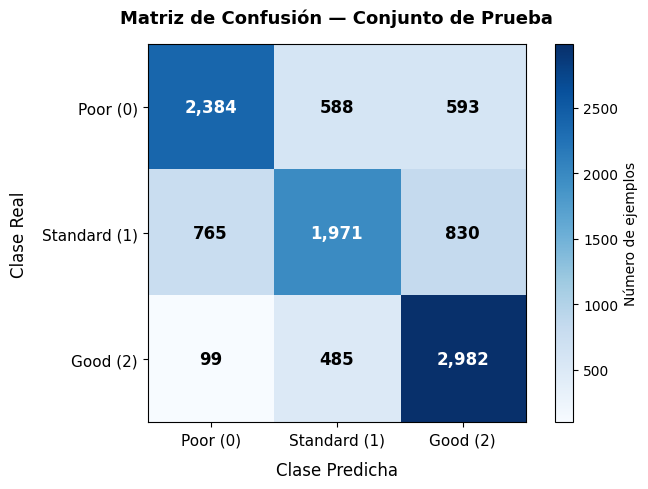


Accuracy por clase:
  Poor      : 66.9%  (2,384 / 3,565)
  Standard  : 55.3%  (1,971 / 3,566)
  Good      : 83.6%  (2,982 / 3,566)


In [15]:
# Construye la matriz de confusión manualmente (sin sklearn)
conf_matrix = np.zeros((num_labels, num_labels), dtype=int)
for true, pred in zip(y_test, pred_test):
    conf_matrix[true][pred] += 1

# ── Visualización ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))

im = ax.imshow(conf_matrix, cmap='Blues')
plt.colorbar(im, ax=ax, label='Número de ejemplos')

# Etiquetas de ejes
clases = ['Poor (0)', 'Standard (1)', 'Good (2)']
ax.set_xticks(range(num_labels));  ax.set_xticklabels(clases, fontsize=11)
ax.set_yticks(range(num_labels));  ax.set_yticklabels(clases, fontsize=11)
ax.set_xlabel('Clase Predicha',  fontsize=12, labelpad=10)
ax.set_ylabel('Clase Real',      fontsize=12, labelpad=10)
ax.set_title('Matriz de Confusión — Conjunto de Prueba', fontsize=13, fontweight='bold', pad=15)

# Anota cada celda con el conteo
for i in range(num_labels):
    for j in range(num_labels):
        color = 'white' if conf_matrix[i, j] > conf_matrix.max() * 0.6 else 'black'
        ax.text(j, i, f'{conf_matrix[i, j]:,}', ha='center', va='center',
                fontsize=12, fontweight='bold', color=color)

plt.tight_layout()
plt.show()

# ── Accuracy por clase ─────────────────────────────────────────────────────────
print("\nAccuracy por clase:")
for c, nombre in enumerate(['Poor', 'Standard', 'Good']):
    total   = conf_matrix[c].sum()
    acierto = conf_matrix[c, c]
    print(f"  {nombre:10s}: {acierto/total*100:.1f}%  ({acierto:,} / {total:,})")


---

## 9. Visualización: Perfil de Características de un Cliente

Se grafica el vector normalizado de características del primer cliente del dataset  
para visualizar cómo se distribuyen los valores de sus atributos financieros.


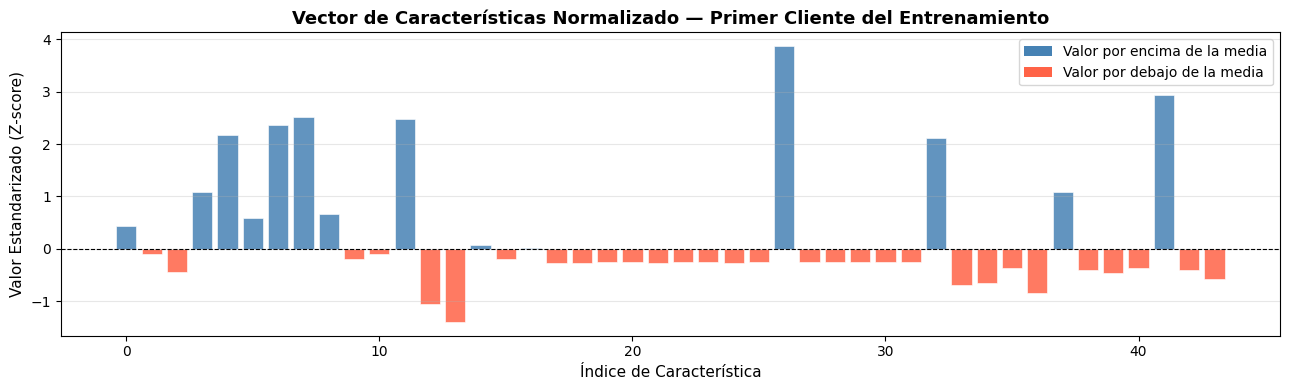

Clase real del primer cliente: Poor (0)
Clase predicha:                Poor (0)


In [16]:
fig, ax = plt.subplots(figsize=(13, 4))

colores = ['steelblue' if v >= 0 else 'tomato' for v in X_train[0]]
ax.bar(range(n), X_train[0], color=colores, alpha=0.85, edgecolor='white', linewidth=0.5)

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Vector de Características Normalizado — Primer Cliente del Entrenamiento',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Índice de Característica', fontsize=11)
ax.set_ylabel('Valor Estandarizado (Z-score)', fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Leyenda de color
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='steelblue', label='Valor por encima de la media'),
                   Patch(facecolor='tomato',    label='Valor por debajo de la media')]
ax.legend(handles=legend_elements, fontsize=10, loc='upper right')

plt.tight_layout()
plt.show()

clase_real = {0: 'Poor', 1: 'Standard', 2: 'Good'}
print(f"Clase real del primer cliente: {clase_real[y_train[0]]} ({y_train[0]})")
print(f"Clase predicha:                {clase_real[pred_train[0]]} ({pred_train[0]})")


---

## 10. Conclusiones

| Aspecto                    | Resultado / Observación                                         |
|:---------------------------|:----------------------------------------------------------------|
| Modelo                     | Regresión Logística Multiclase (OvA, implementación manual)    |
| Optimizador                | L-BFGS-B vía `scipy.optimize.minimize`                          |
| Características            | Variables financieras normalizadas (Z-score)                    |
| Balance de clases          | Undersampling de clases mayoritarias al mínimo de la clase minoritaria |
| Regularización             | L2 con $\lambda = 0.01$                                        |

**Interpretación del accuracy:**  
Con 3 clases perfectamente balanceadas, una predicción aleatoria daría ~33%.  
El modelo supera ampliamente esa línea base, capturando patrones lineales en el espacio de características.

**Limitaciones y posibles mejoras:**

> 💡 La Regresión Logística asume **fronteras de decisión lineales**. Para mayor precisión se pueden explorar:
> - **Random Forest / Gradient Boosting** — capturan relaciones no lineales entre variables financieras.
> - **Redes Neuronales (MLP)** — modelas interacciones complejas entre características.
> - **Validación cruzada k-fold** — estimación más robusta del rendimiento real.
> - **Métricas adicionales** — Precision, Recall y F1-score por clase para análisis de riesgo.
